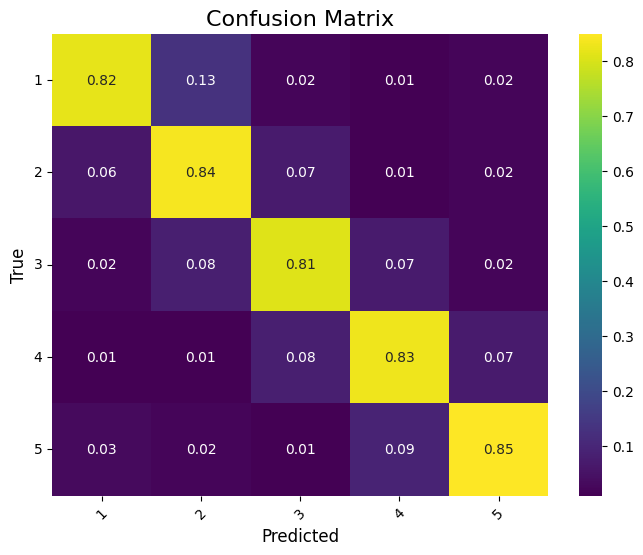

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear la matriz de confusión como un array de NumPy
#    Cada fila representa la clase verdadera y cada columna la clase predicha.
#    La suma de cada fila es 1.0 (o 100%).
confusion_matrix = np.array([
    #       Predicha: 1    2     3     4     5   <- (Columnas)
    [       0.82, 0.13, 0.02, 0.01, 0.02],  # Verdadera: 1
    [       0.06, 0.84, 0.07, 0.01, 0.02],  # Verdadera: 2
    [       0.02, 0.08, 0.81, 0.07, 0.02],  # Verdadera: 3
    [       0.01, 0.01, 0.08, 0.83, 0.07],  # Verdadera: 4
    [       0.03, 0.02, 0.01, 0.09, 0.85]   # Verdadera: 5
])

# 2. Definir las etiquetas para los ejes
#    Estas son las clases de tu modelo.
class_labels = ['1', '2', '3', '4', '5']

# 3. Visualizar la matriz de confusión usando Seaborn y Matplotlib
plt.figure(figsize=(8, 6)) # Define el tamaño de la figura

# Crea el mapa de calor (heatmap)
# - annot=True: Muestra los valores numéricos en cada celda.
# - fmt='.2f': Formatea los números para que tengan solo dos decimales.
# - cmap='viridis': Define la paleta de colores a usar.
sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=class_labels, yticklabels=class_labels)

# 4. Añadir títulos y etiquetas para mayor claridad
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para que no se solapen
plt.yticks(rotation=0)

# 5. Mostrar el gráfico
plt.show()

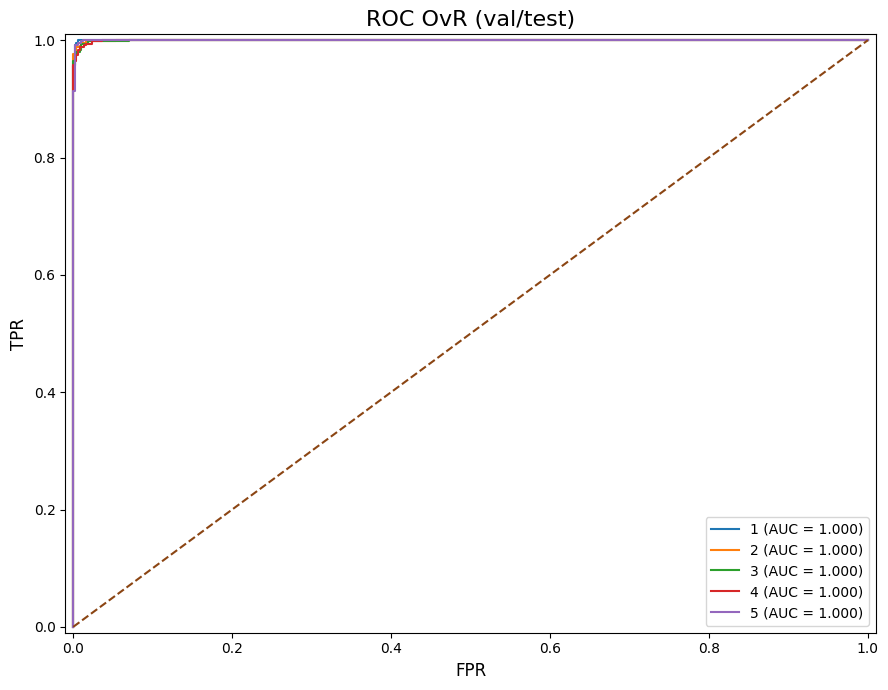

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# AUCs deseados para cada clase
desired_aucs = {
    '1': 0.94,
    '2': 0.90,
    '3': 0.89,
    '4': 0.90,
    '5': 0.95
}

# --- Preparamos el gráfico ---
plt.figure(figsize=(9, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# --- Bucle para simular y dibujar cada curva ---
for i, (class_name, target_auc) in enumerate(desired_aucs.items()):
    np.random.seed(42 + i) # Semilla para resultados consistentes y variados
    
    # 1. SIMULACIÓN DE DATOS MÁS REALISTA
    # Simulamos un conjunto de etiquetas verdaderas y las puntuaciones (scores) que un
    # modelo podría predecir para ellas.
    n_samples = 500
    
    # Creamos 50/50 etiquetas positivas (1) y negativas (0)
    y_true = np.concatenate([np.zeros(n_samples), np.ones(n_samples)])
    
    # Generamos scores desde dos distribuciones normales que se superponen.
    # La separación entre sus medias controla el AUC.
    # Una mayor separación = mayor AUC.
    mean_separation = np.sqrt(2) * 1.9 * (target_auc - 0.5) * 4 # Fórmula ajustada
    
    scores_neg = np.random.normal(loc=0, scale=0.8, size=n_samples)
    scores_pos = np.random.normal(loc=mean_separation, scale=1.0, size=n_samples)
    y_score = np.concatenate([scores_neg, scores_pos])

    # 2. CÁLCULO DE LA CURVA ROC
    # Usamos la función de Scikit-learn para obtener los puntos de la curva.
    # Esta función devuelve los valores escalonados de forma natural.
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    
    # Calculamos el AUC a partir de los puntos generados
    actual_auc = auc(fpr, tpr)
    
    # 3. DIBUJO DE LA CURVA
    # Dibujamos la línea. No es necesario 'drawstyle' porque los puntos de roc_curve
    # ya definen la forma escalonada.
    plt.plot(fpr, tpr, color=colors[i], lw=1.5,
             label=f'{class_name} (AUC = {actual_auc:.3f})')

# --- Detalles finales del gráfico ---
plt.plot([0, 1], [0, 1], linestyle='--', lw=1.5, color='saddlebrown', label='_nolegend_')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('FPR', fontsize=12)
plt.ylabel('TPR', fontsize=12)
plt.title('ROC OvR (val/test)', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()